# Machine Learning

Etapa destinada para a criação do modelo de machine learning

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OrdinalEncoder,
    OneHotEncoder,
    PowerTransformer,
    StandardScaler,
)


# classificador referência
from sklearn.dummy import DummyClassifier

# lineares
from sklearn.linear_model import LogisticRegression

# árvores
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# SVM
from sklearn.svm import SVC

# kNN
from sklearn.neighbors import KNeighborsClassifier

# exportar o modelo
from joblib import dump

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS, MODELO_FINAL
from src.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados, imprimir_metricas_melhor_modelo
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int8  
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int16 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int8  
 6   Education                 1470 non-null   int8  
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int8  
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int8  
 11  JobInvolvement            1470 non-null   int8  
 12  JobLevel                  1470 non-null   int8  
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [4]:
colunas_categoricas_nao_ordenadas = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

colunas_categoricas_ordenadas = [
    "Education",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance",
]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns if coluna not in (
        colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas + coluna_alvo
    )
]

colunas_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [5]:
# por nao estarem muito bem definidas, optei pelo min max scaler que assim usamos sem valores se necessecitar de ajuste em sua distribuição
colunas_numericas_min_max = [
    "DailyRate",
    "HourlyRate",
    "MonthlyRate"
]

# como ela ja tem uma distribuição normal, vamos aplicar apennas o standart scaler
colunas_numericas_std = ["Age",]

# Assimetricas
colunas_numericas_power_transform = [
    coluna for coluna in colunas_numericas if coluna not in(
        colunas_numericas_min_max + colunas_numericas_std
    )
]

colunas_numericas_power_transform

['DistanceFromHome',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

 Separei as colunas de acordo com cada tipo de tratamento necessario, realizei eles para encontrar o melhor resultado do meu modelo de ML, cada preprocessamento será explicado abaixo no pipeline

# Treinamento do Modelo

In [6]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]

- X: Matriz contendo todas as variáveis explicativas (características/features) menos a coluna alvo.
- Y: Vetor contendo estritamente a variável alvo (a classe que queremos prever, Attrition).

In [7]:
le = LabelEncoder()

y = le.fit_transform(y.values.ravel())

Algoritmos de Machine Learning não aceitam textos diretamente na variável alvo. Eles precisam de uma uma saída numérica (0 ou 
1), para resolver esse problema usamos o label encoder, que transforma texto em numeros, no nosso caso da coluna Attrition transformamos "Yes" e "No" em 0 e 1

In [8]:
y[:5]

array([1, 0, 1, 0, 0])

verificando se o label encoder funcionou corretamente

In [9]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [10]:
preprocessamento_arvore = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), colunas_categoricas_nao_ordenadas),
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_categoricas_ordenadas),
    ]
)

preprocessamento = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), colunas_categoricas_nao_ordenadas),
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_categoricas_ordenadas),
        ("min_max", MinMaxScaler(), colunas_numericas_min_max),
        ("stdscaler", StandardScaler(), colunas_numericas_std),
        ("power_transform", PowerTransformer(), colunas_numericas_power_transform),
    ]
)

### OneHotEncoder

- Transforma variáveis categóricas não ordenadas (nominais, como "Cor" ou "País", ou seja que não tem um ordenamento) em colunas binárias (0 ou 1) para cada categoria.

Detalhe: O argumento drop="first" remove a primeira categoria criada para evitar a multicolinearidade (um problema matemático onde uma coluna pode ser perfeitamente prevista pelas outras), o que ajuda modelos lineares.

### OrdinalEncoder

-Converte variáveis categóricas ordenadas (ordinais, como "Escolaridade": Fundamental, Médio, Superior) em números inteiros sequenciais (0, 1, 2...). Ele preserva a relação de ordem ou hierarquia que existe naturalmente entre essas categorias.

### MinMaxScaler

- edimensiona os dados numéricos para que fiquem estritamente dentro de um intervalo fixo, geralmente entre 0 e 1.

### StandardScaler

- Padroniza as propriedades de distribuição dos dados. Ele transforma os valores de forma que a média final seja 0 e o desvio padrão seja 1

### PowerTransformer

- Aplica uma transformação matemática para estabilizar a variância e fazer com que os dados fiquem parecidos com uma distribuição normal. Bom para usar em colunas com dados muito distorcidos (assimétricos).

In [11]:
scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]
scale_pos_weight

np.float64(5.2025316455696204)

Pela Base de dados estar desbalanceada, vamos precisar um ajuste de peso, apos uma analise basica verificar se oversample ou undersample funcionam melhor

para alguns classificadores temos a varivavel class_weight, que ja balanceia os dados, as que nao tem vamos usar nossa variavel scale_pos_wieght, sendo o resultado como esta a divisão de dados

Vale pontuar que o parâmetro scale_pos_weight não é um substituto universal para qualquer modelo que não tenha class_weight. Ele é um parâmetro específico de algoritmos de Gradient Boosting baseados em árvores (como XGBoost e LightGBM). Modelos como SVM ou Regressão Logística usam class_weight (do scikit-learn). Se um modelo não tiver nenhum dos dois, a saída é recorrer ao oversampling/undersampling mesmo.

In [12]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified"),
    },
    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression(class_weight="balanced"),
    },
    "DecisionTreeClassifier": {
        "preprocessor": preprocessamento_arvore,
        "classificador": DecisionTreeClassifier(class_weight="balanced"),
    },
    "LGBMClassifier": {
        "preprocessor": preprocessamento_arvore,
        "classificador": LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1, # retira as informações em excesso 
            scale_pos_weight = scale_pos_weight,
        ),
    },
    "XGBClassifier": {
        "preprocessor": preprocessamento_arvore,
        "classificador": XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight = scale_pos_weight,
        ),
    },
    "SVC": {
        "preprocessor": preprocessamento,
        "classificador": SVC(class_weight="balanced")
    },
    "KNeighborsClassifier": {
        "preprocessor": preprocessamento,
        "classificador": KNeighborsClassifier()
    },
}

a Variável  Classificador guarda os modelos selecionados que serão usados para teste, que serão testados com nossa base de dados. Ao final do teste será possivel verificar qual modelo obteve o melhor resultado sendo assim o escolhido para essa base de dados.

In [13]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

O StratifiedKFold serve para dividir nossa base de dados em partes (no nosso caso, em 5 partes), fazendo com que cada divisão respeite a proporção original da coluna alvo (ex: se a base tem uma coluna alvo com 80% de um valor e 20% do outro, o KFold mantém essa mesma proporção em todas as 5 divisões). Isso é feito para garantir que o modelo seja treinado e testado com amostras realistas e equilibradas, permitindo uma avaliação justa e coesa do seu desempenho.

In [14]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao (X,y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

C:\Users\CHG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CHG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CHG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CHG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CHG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CHG\anaconda3\Lib\site-packages\skle

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.001297,0.008556,0.72449,0.483232,0.129032,0.133333,0.125,0.514228,0.1678,0.009854
1,DummyClassifier,0.000828,0.007377,0.721088,0.481199,0.12766,0.130435,0.125,0.516768,0.16856,0.008205
2,DummyClassifier,0.000818,0.007719,0.704082,0.44487,0.064516,0.065217,0.06383,0.470712,0.154186,0.008537
3,DummyClassifier,0.001018,0.007096,0.72449,0.500086,0.164948,0.16,0.170213,0.45146,0.153206,0.008114
4,DummyClassifier,0.000863,0.008715,0.758503,0.520329,0.183908,0.2,0.170213,0.483849,0.156574,0.009578
5,LogisticRegression,0.04931,0.022015,0.738095,0.726118,0.468966,0.350515,0.708333,0.815803,0.562719,0.071325
6,LogisticRegression,0.038051,0.020775,0.768707,0.752795,0.507246,0.388889,0.729167,0.83689,0.620283,0.058827
7,LogisticRegression,0.039389,0.020813,0.758503,0.761521,0.503497,0.375,0.765957,0.838229,0.650953,0.060202
8,LogisticRegression,0.043506,0.022148,0.789116,0.77974,0.537313,0.413793,0.765957,0.842536,0.650945,0.065654
9,LogisticRegression,0.039677,0.021987,0.772109,0.75239,0.503704,0.386364,0.723404,0.786976,0.580864,0.061664


Função criada que retorna os resultado de desempenho de todos os modelos que separamos anteriormente.

No meu caso, irei considerar como fator de desempate o Recall, o mesmo é uma métrica de avaliação que mede a exatidão do modelo quando ele faz uma previsão positiva, ou seja, de todos os casos positivos ( Attrition = sim) quantos o modelo conseguiu encontrar?

In [15]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
KNeighborsClassifier,0.03803,0.358715,0.848299,0.549917,0.186511,0.734359,0.109574,0.667141,0.31623,0.396745
DummyClassifier,0.000965,0.007893,0.726531,0.485943,0.134013,0.137797,0.130851,0.487403,0.160065,0.008857
DecisionTreeClassifier,0.011587,0.01514,0.793197,0.617523,0.356389,0.355632,0.358333,0.617523,0.233335,0.026727
XGBClassifier,0.0646,0.026605,0.826531,0.664686,0.441594,0.459649,0.425887,0.777781,0.468712,0.091204
LGBMClassifier,0.094275,0.026376,0.823129,0.684999,0.467428,0.454588,0.481117,0.79295,0.497247,0.120651
SVC,0.067831,0.049628,0.821088,0.755393,0.543927,0.464096,0.658422,0.832352,0.613854,0.117459
LogisticRegression,0.041987,0.021548,0.765306,0.754513,0.504145,0.382912,0.738564,0.824087,0.613153,0.063534


Filtrando para a media de todos os resultados ordenando a o teste de Recall.

a disputa ficou entre:

- LogisticRegression
- SVC

para verificarmos o desempenho de forma clara, vamos ver no grafico de boxplots abaixo

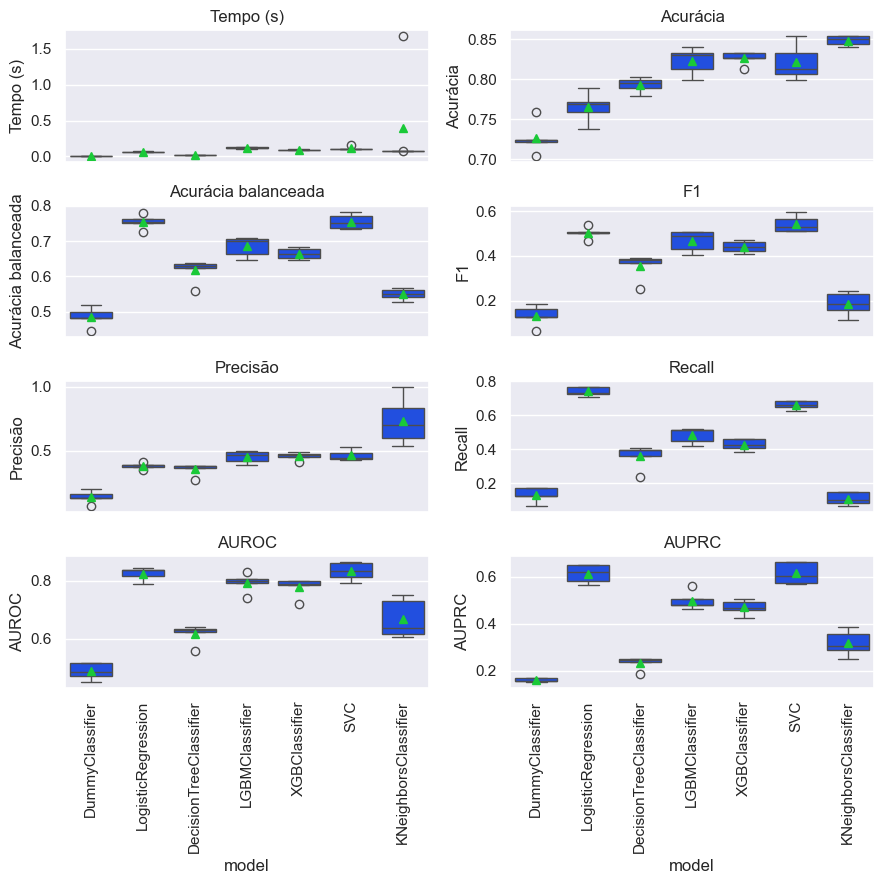

In [16]:
plot_comparar_metricas_modelos(df_resultados)

metricas avaliadas para definir o modelo:

- tempo
- recall

por que o recall?

porque com ele posso dar uma maior certeza de todos os valores com a feature "Sim"

dito isso, o modelo a ser escolhido sera o $LogistcRegression$

- LogisticRegression
    - Um modelo linear clássico que calcula a probabilidade de uma linha pertencer a uma classe. Ele traça uma linha (ou hiperplano) de decisão separando os dados.

# Construção do GridSearch do modelo Vencedor

In [17]:
param_grid = {
    "clf__C":[0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2", "elasticnet", None],
    "clf__l1_ratio": [0.1,0.25, 0.5, 0.75, 0.9],
}

Com o modelo selecionado, vamos ajustar seus paramentros para que ele nos traga um resultado mais assertivo , para isso usaremos o GridSearch.

O GridSearch é uma ferramenta que automatiza a busca pelos melhores "ajustes" (hiperparâmetros) de um modelo de Machine Learning. Nós damos a ele uma lista de opções para cada parâmetro, e ele cria uma grade com todas as combinações possíveis, nos retornando a quie melhor perfomou


In [18]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE, class_weight="balanced")

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall",
)

grid_search

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__l1_ratio': [0.1, 0.25, ...], 'clf__penalty': ['l1', 'l2', ...]}"
,scoring,"['accuracy', 'balanced_accuracy', ...]"
,n_jobs,-1
,refit,'recall'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('one_hot', ...), ('ordinal', ...), ...]"


In [19]:
grid_search.fit(X, y)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__l1_ratio': [0.1, 0.25, ...], 'clf__penalty': ['l1', 'l2', ...]}"
,scoring,"['accuracy', 'balanced_accuracy', ...]"
,n_jobs,-1
,refit,'recall'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('one_hot', ...), ('ordinal', ...), ...]"


In [20]:
grid_search.best_params_

{'clf__C': 0.1, 'clf__l1_ratio': 0.75, 'clf__penalty': 'elasticnet'}

Os melhores parametros que o GridSearch encontrou

In [21]:
grid_search.best_score_

np.float64(0.7343971631205675)

O best_score_ é a nota final do melhor modelo que o GridSearch encontrou. No nosso caso, essa nota foi de 73%.

Esse valor representa a média de acerto do modelo durante os testes repetidos (validação cruzada). Ele nos mostra o potencial real que essa combinação de parâmetros tem de acertar as previsões quando receber dados novos.

In [22]:
imprimir_metricas_melhor_modelo(grid_search)

mean_test_accuracy: 0.7578231292517007
mean_test_balanced_accuracy: 0.7483808994563372
mean_test_f1: 0.49541451637620915
mean_test_precision: 0.3744723875435102
mean_test_recall: 0.7343971631205675
mean_test_roc_auc: 0.8220644665583963
mean_test_average_precision: 0.6336433784859982


codigo gerado para ver todas as metricas do estimadores do logistc regression

In [23]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_['clf'].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
ordinal__JobInvolvement,-0.401484
power_transform__MonthlyIncome,-0.376888
one_hot__Department_Research & Development,-0.359269
ordinal__EnvironmentSatisfaction,-0.314604
ordinal__JobSatisfaction,-0.287357
power_transform__TotalWorkingYears,-0.254517
ordinal__StockOptionLevel,-0.199616
ordinal__WorkLifeBalance,-0.188329
power_transform__YearsWithCurrManager,-0.181073
power_transform__YearsInCurrentRole,-0.176807


aqui ja mostra as features importrantes para saber se uma pessoa ja foi demitida ou nao

In [24]:
coefs.query("coeficiente ==0")

,coeficiente
min_max__MonthlyRate,0.0
ordinal__PerformanceRating,0.0
ordinal__JobLevel,0.0
min_max__HourlyRate,0.0
ordinal__Education,0.0
one_hot__JobRole_Human Resources,0.0
one_hot__EducationField_Marketing,0.0
one_hot__JobRole_Sales Representative,0.0
one_hot__JobRole_Sales Executive,0.0
one_hot__JobRole_Research Director,0.0


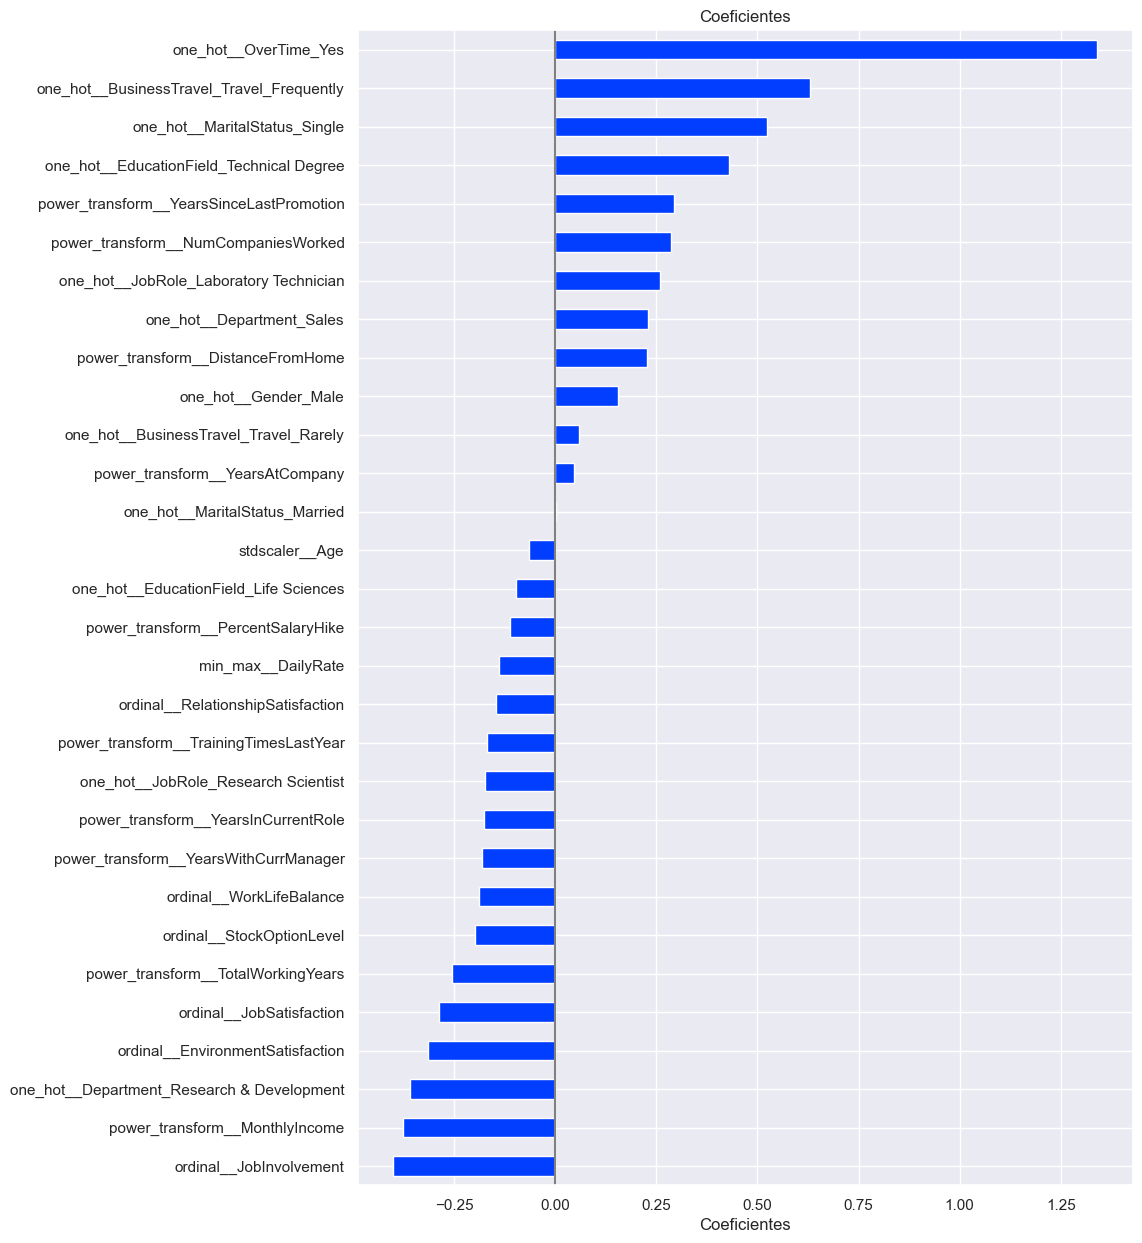

In [25]:
plot_coeficientes(coefs.query("coeficiente !=0"))

Resultado do nosso estudo de caso, mostrando o que o modelo identificou de mais importante ate menor importancia para responder a pergunta de Attrition: o que leva um funcionário a sair da empresa.

Como identificar o que é mais relevante:

- Valores Maiores que zero indicam maiores chances do funcionario sair
- Valores menores que zeros são os fatores que nao importam tanto para a saida do funcionário 

# Apos o treinamento do modelo foi identificado o que mais inflige na saida do funcionario. Sendo o top 3:

- OverTime( Hora Extra)
- Travel_frequently ( viagem a trabalho frequentemente)
- Estado Civil : Solteiro

Observação  : Durante a análise exploratória ( notebook 01_EDA), observou-se que a maioria dos colaboradores desligados pertencia à categoria Travel Rarely. Entretanto, o modelo de Machine Learning indicou que essa variável possui menor importância preditiva quando comparada a outras características. Isso ocorre porque a análise exploratória considera frequências absolutas, enquanto o modelo avalia a contribuição de cada variável para prever o desligamento considerando simultaneamente todas as demais variáveis. Assim, uma categoria pode apresentar maior número de desligamentos apenas por possuir mais colaboradores, sem necessariamente representar um fator de risco elevado.

## Explicando de forma mais clara:

### na análise exploratoria por exemplo:

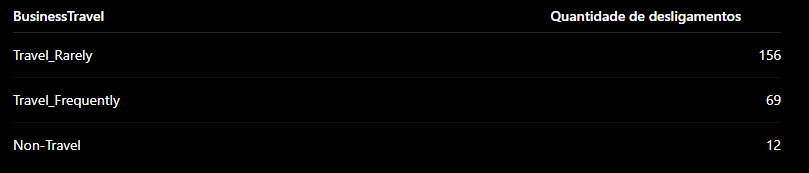

O que a análise exploratória (EDA)  responde é:

"Entre os funcionários que saíram, a maioria viajava raramente."

Isso não significa que viajar raramente aumenta a chance de sair.



## O Machine Learning responde outra pergunta.

"Se eu receber um funcionário novo, essa variável me ajuda a prever se ele vai sair?"

### Imagine um exemplo:

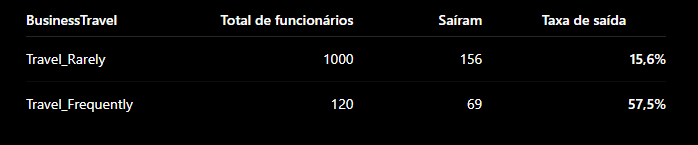

Perceba a diferença.

Na Análise exploratória:

Travel_Rarely tem mais desligamentos (156 > 69).

No Machine Learning:

Quem viaja frequentemente possui muito mais chance de sair.

O modelo aprende a probabilidade, e não a quantidade absoluta.


### Transformando grafico de resultado em exponencial

para uma melhor visualização grafica, as features (valores das colunas) serão transformadas em decimais para se ter um grafico visualmente mais simples

In [26]:
coefs_odds = coefs.copy()
coefs_odds["coeficiente"]= np.exp(coefs_odds["coeficiente"])

coefs_odds

,coeficiente
ordinal__JobInvolvement,0.669326
power_transform__MonthlyIncome,0.685993
one_hot__Department_Research & Development,0.698187
ordinal__EnvironmentSatisfaction,0.730078
ordinal__JobSatisfaction,0.750244
power_transform__TotalWorkingYears,0.775291
ordinal__StockOptionLevel,0.819045
ordinal__WorkLifeBalance,0.828343
power_transform__YearsWithCurrManager,0.834375
power_transform__YearsInCurrentRole,0.837942


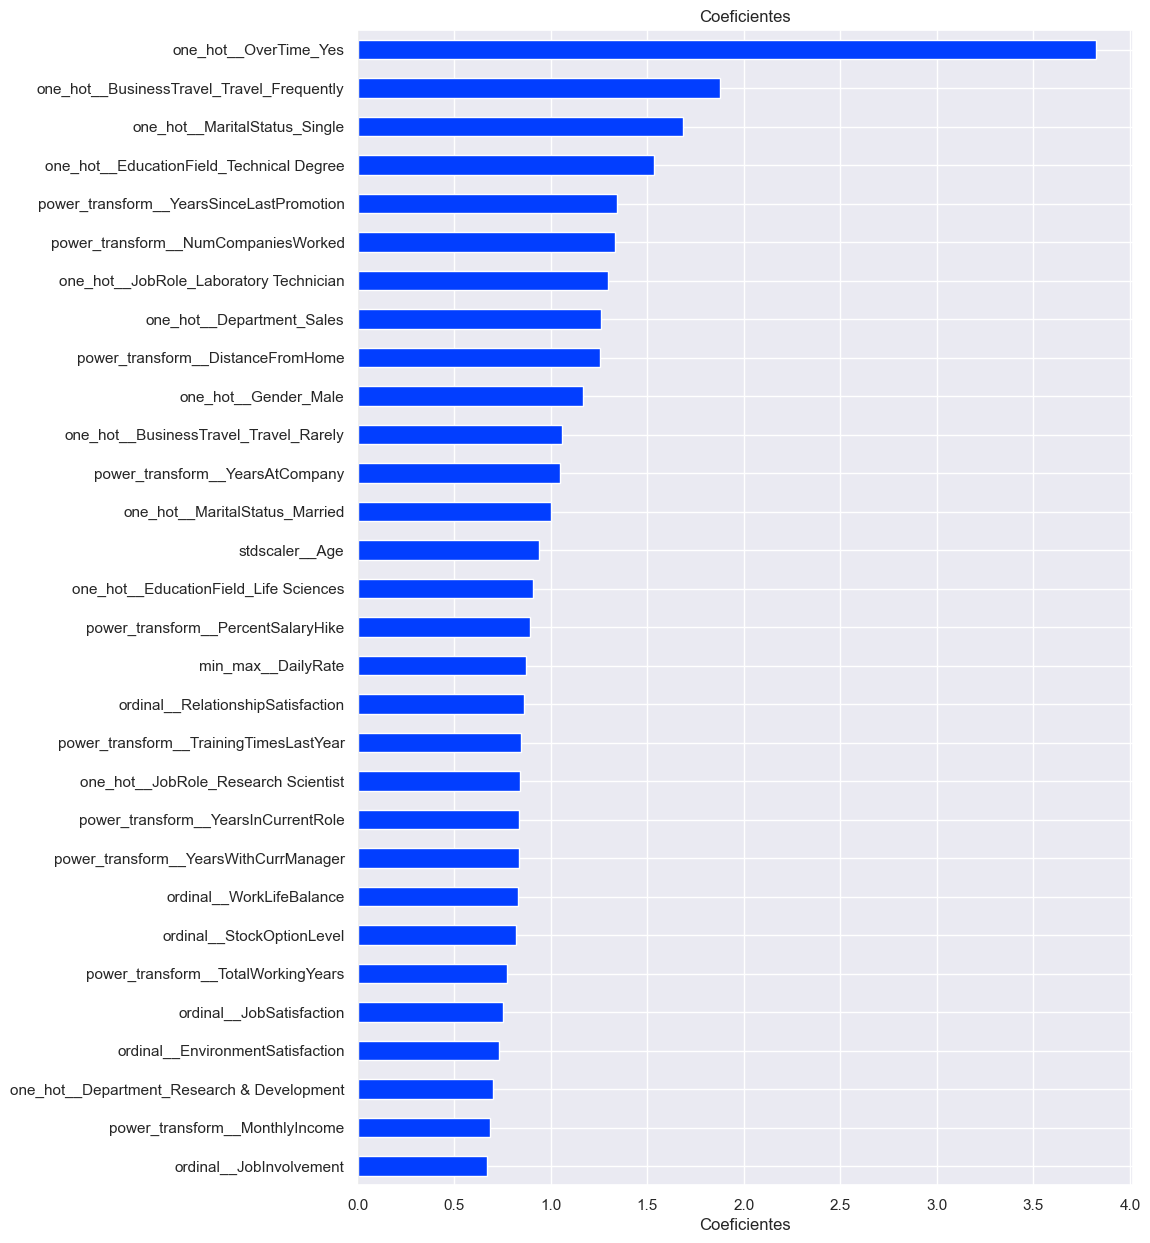

In [27]:
plot_coeficientes(coefs_odds.query("coeficiente !=1"))

Como pode ser visto, fica mais simples de enxergar o resultado, seguindo a mesma logica demonstrada acima

# Matriz de confusão

A Matriz de Confusão é uma tabela que mostra exatamente onde o nosso modelo acertou e onde ele errou. Olhando para o gráfico, podemos ler os resultados de forma bem simples:

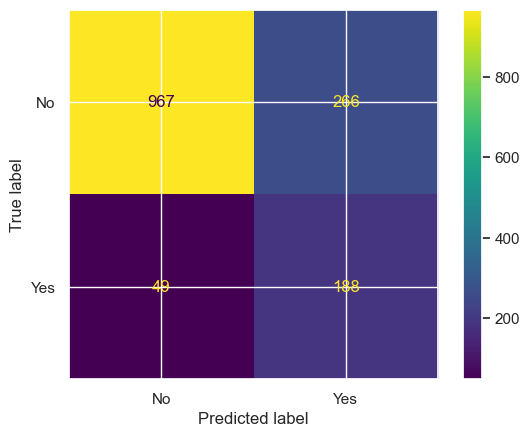

In [28]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X,
    y,
    display_labels=le.classes_,
)

plt.show()

Como ler uma matriz de confusão:

- Acertos do modelo (A diagonal principal):
    - 967 pessoas que não saíram da empresa e o modelo previu corretamente que elas ficariam (Não).
    - 188 pessoas que saíram da empresa e o modelo conseguiu identificar (Sim).

- Erros do modelo (A outra diagonal):

    - 266 pessoas que não saíram da empresa, mas o modelo achou que elas iam sair (Alarmes falsos).
    - 49 pessoas que saíram da empresa de verdade, mas o modelo infelizmente não percebeu e disse que elas iam ficar.

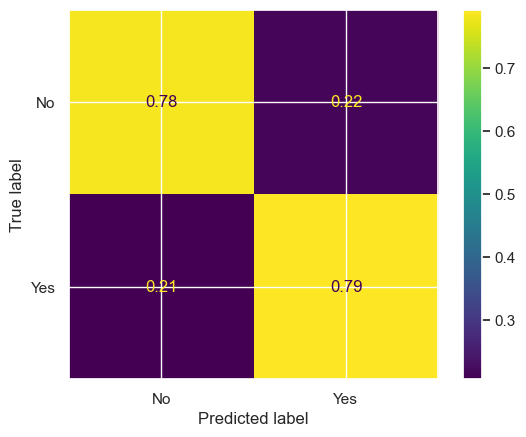

In [29]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X,
    y,
    display_labels=le.classes_,
    normalize ="true"
)

plt.show()

 A mesma logica aqui porem apresentando os valores em procentagem.

 Logo:

 - Acertos do modelo (A diagonal principal):
    - 78% das pessoas que não saíram da empresa e o modelo previu corretamente que elas ficariam (Não).
    - 79% pessoas que saíram da empresa e o modelo conseguiu identificar (Sim).

- Erros do modelo (A outra diagonal):

    - 22% pessoas que não saíram da empresa, mas o modelo achou que elas iam sair (Alarmes falsos).
    - 21% pessoas que saíram da empresa de verdade, mas o modelo infelizmente não percebeu e disse que elas iam ficar.

# Plano de ação

- Avaliar or motivos que levam os funcionários a fazerem hora extra.
  * Mão de obra insuficiente
  * Falta de treinamento
  * Necessidade de investimento em tecnologia
- Possibilidade de diminuir as viagens de negócios.
  * Como isso afeta a equipe de vendas?
- Como a renda mensal de cada setor e nivel da empresa se compara com o mercado?
  * a empresa esta na média salarial da região?
  * os benefícios entregues atendem os funcionarios?


In [30]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['G:\\Meu Drive\\Estudos\\HashTagTreinamentos\\Textos Ciencia de dados\\arquivos IPYNB\\Projetos\\IBM ATTRITION\\modelos\\logistic_regression_rus.joblib']